# **DATA**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [51]:
import pandas as pd
import numpy as np


df = pd.read_csv('/content/drive/MyDrive/TPM/shoppers.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## **EKSPLORASI DATA**

In [53]:
categorical_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

df[categorical_cols] = df[categorical_cols].astype("category")

## **FEATURE ENGINEERING**

## **Set Peubah Baru**

In [54]:
df['nPages_Visited'] = df['Administrative'] + df['Informational'] + df['ProductRelated']
df['total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']
df['avg_Administrative_Duration'] = df['Administrative_Duration'] / df['Administrative'].replace(0, 1)
df['avg_Informational_Duration'] = df['Informational_Duration'] / df['Informational'].replace(0, 1)
df['avg_ProductRelated_Duration'] = df['ProductRelated_Duration'] / df['ProductRelated'].replace(0, 1)
df['avg_Duration_Per_Page'] = df['total_Duration'] / df['nPages_Visited'].replace(0, 1)

first_semester_months = ['Feb', 'Mar', 'May', 'June']
df['is_First_Semester'] = df['Month'].isin(first_semester_months).astype(int)

months_list = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for m in months_list:
    df[f'is_{m}'] = (df['Month'] == m).astype(int)

os_list = [1,2,3,4,5,6,7,8]
for o in os_list:
    df[f'is_os_{o}'] = (df['OperatingSystems'] == o).astype(int)

browser_list = [1,2,3,4,5,6,7,8,9,10,11,12,13]
for b in browser_list:
    df[f'is_browser_{b}'] = (df['Browser'] == b).astype(int)

region_list = [1,2,3,4,5,6,7,8,9]
for r in region_list:
    df[f'is_region_{r}'] = (df['Region'] == r).astype(int)

traffic_list = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
for t in traffic_list:
    df[f'is_traffic_{t}'] = (df['TrafficType'] == t).astype(int)

visitor_list = ['Returning_Visitor', 'New_Visitor', 'Other']
for v in visitor_list:
    df[f'is_{v}'] = (df['VisitorType'] == v).astype(int)

In [55]:
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
print(df[['Weekend', 'Revenue']].head())

   Weekend  Revenue
0        0        0
1        0        0
2        0        0
3        0        0
4        1        0


In [56]:
columns_to_remove = ['Month', 'Browser', 'Region','OperatingSystems','TrafficType','VisitorType']
df = df.drop(columns_to_remove, axis=1)

## **Variabel Target**

In [57]:
df['target'] = df['Revenue'].astype(int)
df['target'].value_counts()

,count
target,
0,10422
1,1908


# **PENYIAPAN DATA**

## **Hapus Leak Variabel**

In [58]:
leak_cols = [
    'Revenue'
]

df = df.drop(columns=leak_cols, errors='ignore')

## **Data Splitting**

In [59]:
from sklearn.model_selection import train_test_split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

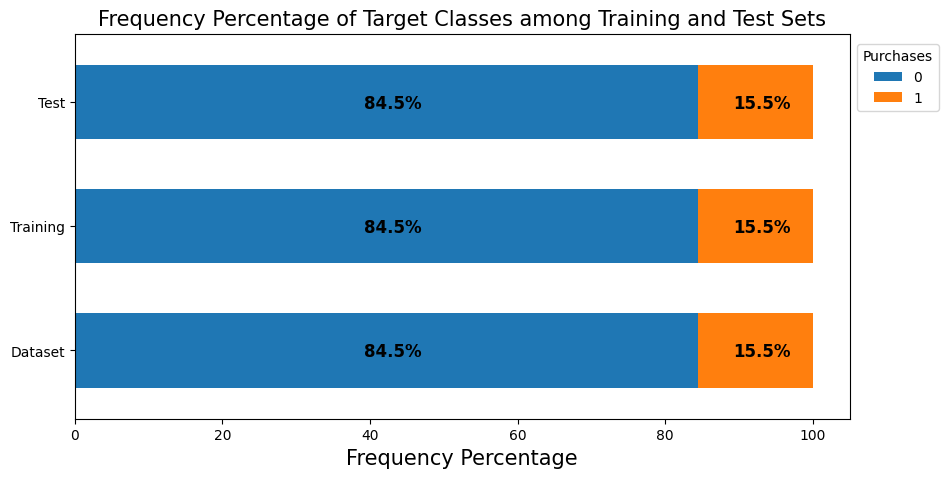

In [60]:
import matplotlib.pyplot as plt
df_perc = pd.concat([y.value_counts(normalize=True).mul(100).round(1),
                     y_train.value_counts(normalize=True).mul(100).round(1),
                     y_test.value_counts(normalize=True).mul(100).round(1)], axis=1)
df_perc.columns=['Dataset','Training','Test']
df_perc = df_perc.T

df_perc.plot(kind='barh', stacked=True, figsize=(10,5), width=0.6)

for idx, val in enumerate([*df_perc.index.values]):
    for (percentage, y_location) in zip(df_perc.loc[val], df_perc.loc[val].cumsum()):
        plt.text(x=(y_location - percentage) + (percentage / 2)-3,
                 y=idx - 0.05,
                 s=f'{percentage}%',
                 color="black",
                 fontsize=12,
                 fontweight="bold")

plt.legend(title='Purchases', loc=(1.01,0.8))
plt.xlabel('Frequency Percentage', fontsize=15)
plt.title('Frequency Percentage of Target Classes among Training and Test Sets', fontsize=15)
plt.show()

In [61]:
y_train.value_counts()

,count
target,
0,8338
1,1526


# **REGRESI LOGISTIK**

## **Library**

In [62]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.model_selection import StratifiedKFold, cross_val_score

import optuna

## **Def Hyperparameter Tuning**

In [ ]:
# def objective(trial):
#     solver = trial.suggest_categorical(
#         'solver',
#         ['liblinear', 'saga']
#     )

#     penalty = trial.suggest_categorical(
#         'penalty',
#         ['l1', 'l2']
#     )

#     C = trial.suggest_float(
#         'C',
#         1e-4,
#         100,
#         log=True
#     )

#     max_iter = trial.suggest_int(
#         'max_iter',
#         500,
#         5000
#     )

#     class_weight = trial.suggest_categorical(
#         'class_weight',
#         [None, 'balanced']
#     )

#     model = Pipeline([
#         ('scaler', StandardScaler()),
#         ('model', LogisticRegression(
#             solver=solver,
#             penalty=penalty,
#             C=C,
#             max_iter=max_iter,
#             class_weight=class_weight,
#             random_state=42
#         ))
#     ])

#     cv = StratifiedKFold(
#         n_splits=5,
#         shuffle=True,
#         random_state=42
#     )

#     score = cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=cv,
#         scoring='average_precision',
#         n_jobs=-1
#     ).mean()

#     return score

## **Def Pre-Processing**

In [63]:
numeric_cols = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'nPages_Visited',
    'total_Duration',
    'avg_Administrative_Duration',
    'avg_Informational_Duration',
    'avg_ProductRelated_Duration',
    'avg_Duration_Per_Page'
]

print("Jumlah Variabel Numerik :", len(numeric_cols))

Jumlah Variabel Numerik : 16


In [64]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

## **Hyperparameter Tuning**

In [ ]:
# study = optuna.create_study(
#     direction='maximize',
#     study_name='logistic_regression_optimization'
# )

# study.optimize(
#     objective,
#     n_trials=100,
#     show_progress_bar=True
# )

[I 2026-05-11 14:27:56,481] A new study created in memory with name: logistic_regression_optimization


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-11 14:28:04,446] Trial 0 finished with value: 0.6445979103778507 and parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.39894670362300744, 'max_iter': 2006, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6445979103778507.
[I 2026-05-11 14:28:05,265] Trial 1 finished with value: 0.6324965880635336 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 20.76481193902214, 'max_iter': 3570, 'class_weight': None}. Best is trial 0 with value: 0.6445979103778507.
[I 2026-05-11 14:28:13,306] Trial 2 finished with value: 0.6426447595232367 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 8.481336045336473, 'max_iter': 3600, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6445979103778507.
[I 2026-05-11 14:28:13,554] Trial 3 finished with value: 0.659163689781712 and parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.002238300306628309, 'max_iter': 1683, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.659163689781712.


In [ ]:
# print("Best ROC-AUC:", study.best_value)
# print("Best Parameters:")
# print(study.best_params)

Best ROC-AUC: 0.6614110443481674
Best Parameters:
{'solver': 'liblinear', 'penalty': 'l1', 'C': 0.0015869990932290139, 'max_iter': 2855, 'class_weight': 'balanced'}


## **Build Model Terbaik**

In [66]:
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        solver='liblinear',
        penalty='l1',
        C=0.0015869990932290139,
        max_iter=2855,
        class_weight='balanced',
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.0015869990932290139,
                                    class_weight='balanced', max_iter=2855,
                                    penalty='l1', random_state=42,
                                    solver='liblinear'))])

In [67]:
y_train_prob = final_model.predict_proba(X_train)[:, 1]
y_test_prob = final_model.predict_proba(X_test)[:, 1]

## **Tuning Threshold**

In [68]:
thresholds = np.arange(0.1, 0.91, 0.01)

f1_scores = []

for threshold in thresholds:
    y_pred_temp = (y_train_prob >= threshold).astype(int)
    score = f1_score(y_train, y_pred_temp)
    f1_scores.append(score)
best_threshold = thresholds[np.argmax(f1_scores)]

print("="*50)
print("BEST THRESHOLD")
print("="*50)
print(f"Best Threshold : {best_threshold:.2f}")
print(f"Best F1-Score  : {max(f1_scores):.4f}")

BEST THRESHOLD
Best Threshold : 0.52
Best F1-Score  : 0.6620


In [69]:
y_train_pred = (y_train_prob >= best_threshold).astype(int)
y_test_pred = (y_test_prob >= best_threshold).astype(int)

## **Evaluasi**

In [70]:
def evaluate_model(y_true, y_pred, y_prob, dataset_name):

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)

    print(f"\n{'='*60}")
    print(f"{dataset_name} PERFORMANCE")
    print(f"{'='*60}")

    print(f"Accuracy           : {acc:.4f}")
    print(f"Balanced Accuracy  : {bal_acc:.4f}")
    print(f"Precision          : {prec:.4f}")
    print(f"Recall             : {rec:.4f}")
    print(f"F1-Score           : {f1:.4f}")
    print(f"ROC-AUC            : {roc_auc:.4f}")

    print("\nClassification Report")
    print(classification_report(
        y_true,
        y_pred,
        zero_division=0
    ))


TRAIN PERFORMANCE
Accuracy           : 0.8813
Balanced Accuracy  : 0.8283
Precision          : 0.5915
Recall             : 0.7516
F1-Score           : 0.6620
ROC-AUC            : 0.9046

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      8338
           1       0.59      0.75      0.66      1526

    accuracy                           0.88      9864
   macro avg       0.77      0.83      0.80      9864
weighted avg       0.90      0.88      0.89      9864


TEST PERFORMANCE
Accuracy           : 0.8820
Balanced Accuracy  : 0.8318
Precision          : 0.5930
Recall             : 0.7592
F1-Score           : 0.6659
ROC-AUC            : 0.9131

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      2084
           1       0.59      0.76      0.67       382

    accuracy                           0.88      2466
   macro avg       0.77      0.83   

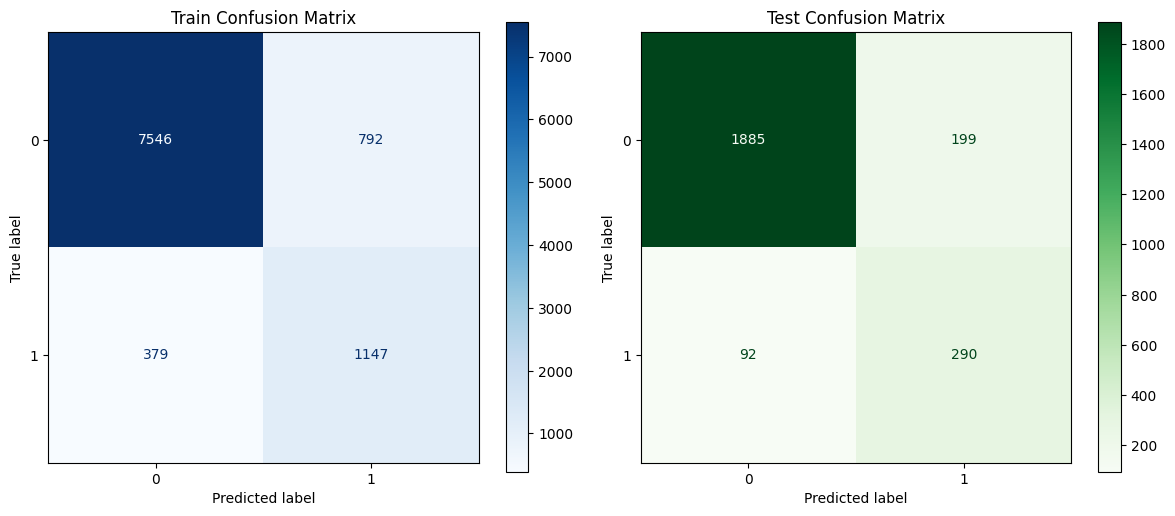

In [71]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import ConfusionMatrixDisplay

evaluate_model(
    y_train,
    y_train_pred,
    y_train_prob,
    "TRAIN"
)

evaluate_model(
    y_test,
    y_test_pred,
    y_test_prob,
    "TEST"
)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# TRAIN
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title('Train Confusion Matrix')

# TEST
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title('Test Confusion Matrix')

plt.tight_layout()
plt.show()

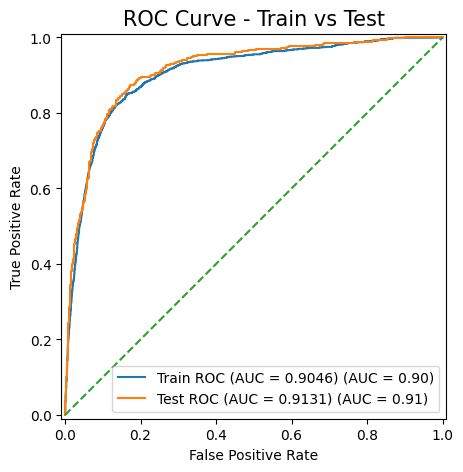

In [72]:
from sklearn.metrics import RocCurveDisplay
fig, ax = plt.subplots(figsize=(12,5))

# Train ROC
RocCurveDisplay.from_predictions(
    y_train,
    y_train_prob,
    ax=ax,
    name=f'Train ROC (AUC = {roc_auc_score(y_train, y_train_prob):.4f})'
)

# Test ROC
RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob,
    ax=ax,
    name=f'Test ROC (AUC = {roc_auc_score(y_test, y_test_prob):.4f})'
)

ax.plot([0,1], [0,1], linestyle='--')
ax.set_title('ROC Curve - Train vs Test', fontsize=15)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

ax.legend(loc='lower right')

plt.show()

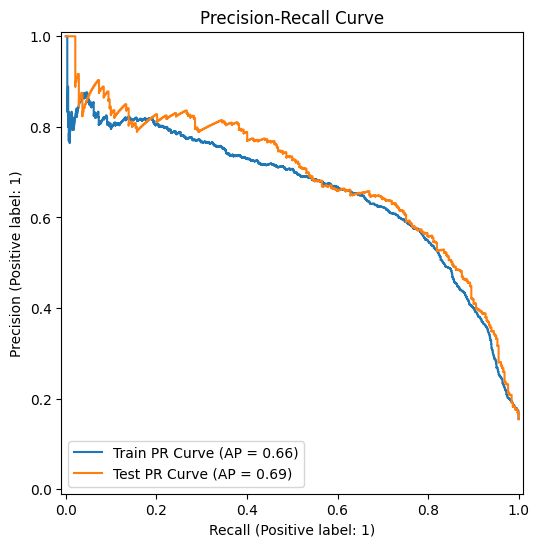

In [73]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(10,6))

# TRAIN
PrecisionRecallDisplay.from_predictions(
    y_train,
    y_train_prob,
    ax=ax,
    name='Train PR Curve'
)

# TEST
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_prob,
    ax=ax,
    name='Test PR Curve'
)

ax.set_title('Precision-Recall Curve')

plt.show()

## **Feature Importance**

In [74]:
model = final_model.named_steps['model']
coefficients = model.coef_[0]
feature_names = X_train.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

importance_df = importance_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

top10_features = importance_df.head(10)

print("\n")
print("="*60)
print("TOP 10 FEATURE IMPORTANCE")
print("="*60)

print(top10_features)



TOP 10 FEATURE IMPORTANCE
                    Feature  Coefficient  Abs_Coefficient
8                PageValues     1.016964         1.016964
28                   is_Nov     0.105131         0.105131
11           nPages_Visited     0.073585         0.073585
7                 ExitRates    -0.070343         0.070343
12           total_Duration     0.025191         0.025191
0            Administrative     0.000000         0.000000
2             Informational     0.000000         0.000000
6               BounceRates     0.000000         0.000000
5   ProductRelated_Duration     0.000000         0.000000
3    Informational_Duration     0.000000         0.000000


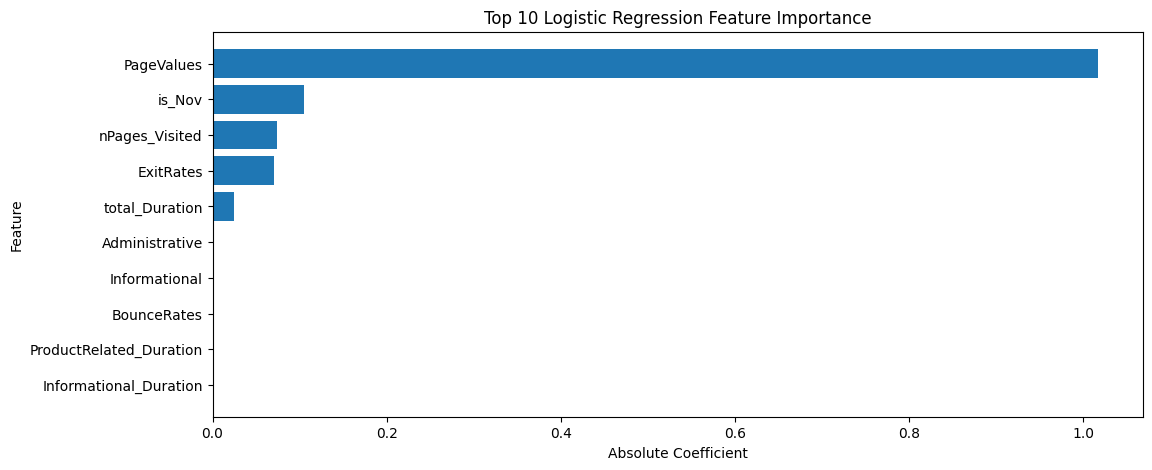

In [75]:
plt.figure(figsize=(12,5))

plt.barh(
    top10_features['Feature'][::-1],
    top10_features['Abs_Coefficient'][::-1]
)

plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.title('Top 10 Logistic Regression Feature Importance')

plt.show()

# **RANDOM FOREST**

## **Library**

In [76]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

import optuna

## **Def Hyperparameter Tuning**

In [ ]:
# def objective_rf(trial):

#     params = {
#         'n_estimators': trial.suggest_int(
#             'n_estimators',
#             200,
#             1500
#         ),

#         'max_depth': trial.suggest_int(
#             'max_depth',
#             3,
#             30
#         ),

#         'min_samples_split': trial.suggest_int(
#             'min_samples_split',
#             2,
#             30
#         ),

#         'min_samples_leaf': trial.suggest_int(
#             'min_samples_leaf',
#             1,
#             20
#         ),

#         'max_features': trial.suggest_categorical(
#             'max_features',
#             ['sqrt', 'log2', None]
#         ),

#         'bootstrap': trial.suggest_categorical(
#             'bootstrap',
#             [True, False]
#         ),

#         'class_weight': trial.suggest_categorical(
#             'class_weight',
#             [None, 'balanced', 'balanced_subsample']
#         ),

#         'ccp_alpha': trial.suggest_float(
#             'ccp_alpha',
#             1e-6,
#             1e-1,
#             log=True
#         ),

#         'random_state': 42,
#         'n_jobs': -1
#     }

#     model = RandomForestClassifier(**params)

#     cv = StratifiedKFold(
#         n_splits=5,
#         shuffle=True,
#         random_state=42
#     )

#     score = cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=cv,
#         scoring='average_precision',
#         n_jobs=-1
#     ).mean()

#     return score

## **Hyperparameter Tuning**

In [ ]:
# study_rf = optuna.create_study(
#     direction='maximize',
#     study_name='random_forest_optimization'
# )

# study_rf.optimize(
#     objective_rf,
#     n_trials=100,
#     show_progress_bar=True
# )

In [ ]:
# print("Best PR-AUC:", study_rf.best_value)
# print("\nBest Parameters:")
# print(study_rf.best_params)

## **Build model Random Forest Terbaik**

In [77]:
rf_model = RandomForestClassifier(
    n_estimators=1311,
    max_depth=9,
    min_samples_split=20,
    min_samples_leaf=19,
    max_features=None,
    bootstrap=True,
    class_weight='balanced_subsample',
    ccp_alpha=2.2179315968457164e-05,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(ccp_alpha=2.2179315968457164e-05,
                       class_weight='balanced_subsample', max_depth=9,
                       max_features=None, min_samples_leaf=19,
                       min_samples_split=20, n_estimators=1311, n_jobs=-1,
                       random_state=42)

In [78]:
train_proba = rf_model.predict_proba(X_train)[:,1]
test_proba  = rf_model.predict_proba(X_test)[:,1]

## **Tuning Threshold**

In [79]:
thresholds = np.arange(0.05, 0.95, 0.01)

best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:

    preds = (train_proba >= threshold).astype(int)

    score = f1_score(y_train, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best Train F1 :", best_f1)

Best Threshold: 0.7300000000000002
Best Train F1 : 0.7509855453350854


In [80]:
train_pred = (train_proba >= best_threshold).astype(int)
test_pred  = (test_proba >= best_threshold).astype(int)

## **Evaluasi**

In [81]:
def evaluate_model(y_true, y_pred, y_prob, dataset_name):

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)

    print(f"\n{'='*60}")
    print(f"{dataset_name} PERFORMANCE")
    print(f"{'='*60}")

    print(f"Accuracy           : {acc:.4f}")
    print(f"Balanced Accuracy  : {bal_acc:.4f}")
    print(f"Precision          : {prec:.4f}")
    print(f"Recall             : {rec:.4f}")
    print(f"F1-Score           : {f1:.4f}")
    print(f"ROC-AUC            : {roc_auc:.4f}")

    print("\nClassification Report")
    print(classification_report(
        y_true,
        y_pred,
        zero_division=0
    ))


TRAIN PERFORMANCE
Accuracy           : 0.8813
Balanced Accuracy  : 0.8283
Precision          : 0.5915
Recall             : 0.7516
F1-Score           : 0.6620
ROC-AUC            : 0.9046

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      8338
           1       0.59      0.75      0.66      1526

    accuracy                           0.88      9864
   macro avg       0.77      0.83      0.80      9864
weighted avg       0.90      0.88      0.89      9864


TEST PERFORMANCE
Accuracy           : 0.8820
Balanced Accuracy  : 0.8318
Precision          : 0.5930
Recall             : 0.7592
F1-Score           : 0.6659
ROC-AUC            : 0.9131

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      2084
           1       0.59      0.76      0.67       382

    accuracy                           0.88      2466
   macro avg       0.77      0.83   

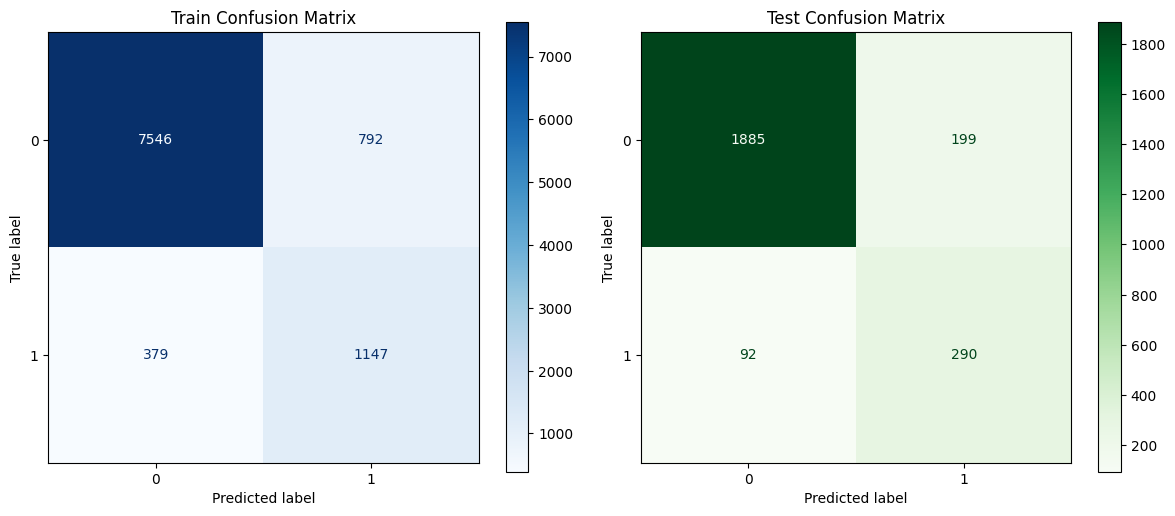

In [82]:
evaluate_model(
    y_train,
    y_train_pred,
    y_train_prob,
    "TRAIN"
)

evaluate_model(
    y_test,
    y_test_pred,
    y_test_prob,
    "TEST"
)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# TRAIN
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_train_pred,
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title('Train Confusion Matrix')

# TEST
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title('Test Confusion Matrix')

plt.tight_layout()
plt.show()

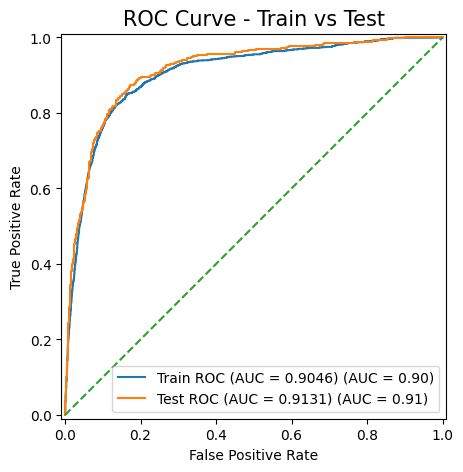

In [83]:
fig, ax = plt.subplots(figsize=(12,5))

# Train ROC
RocCurveDisplay.from_predictions(
    y_train,
    y_train_prob,
    ax=ax,
    name=f'Train ROC (AUC = {roc_auc_score(y_train, y_train_prob):.4f})'
)

# Test ROC
RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob,
    ax=ax,
    name=f'Test ROC (AUC = {roc_auc_score(y_test, y_test_prob):.4f})'
)

ax.plot([0,1], [0,1], linestyle='--')
ax.set_title('ROC Curve - Train vs Test', fontsize=15)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

ax.legend(loc='lower right')

plt.show()

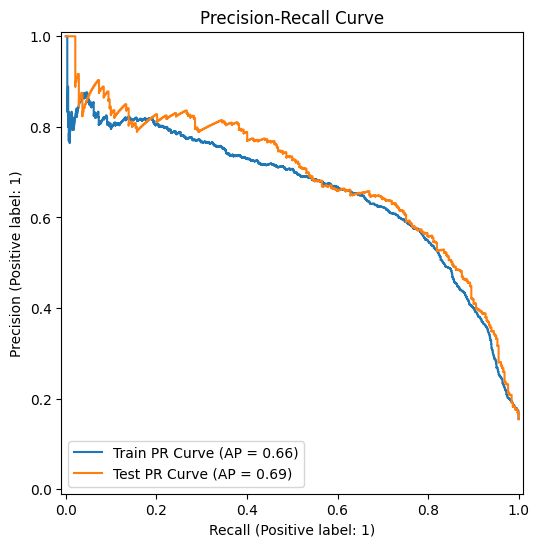

In [84]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(10,6))

# TRAIN
PrecisionRecallDisplay.from_predictions(
    y_train,
    y_train_prob,
    ax=ax,
    name='Train PR Curve'
)

# TEST
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_prob,
    ax=ax,
    name='Test PR Curve'
)

ax.set_title('Precision-Recall Curve')

plt.show()

## **Feature Importance**



TOP 10 FEATURE IMPORTANCE - RANDOM FOREST
                        Feature  Importance
8                    PageValues    0.708659
17            is_First_Semester    0.047946
28                       is_Nov    0.041455
12               total_Duration    0.018501
5       ProductRelated_Duration    0.018454
6                   BounceRates    0.018196
7                     ExitRates    0.016689
4                ProductRelated    0.016337
13  avg_Administrative_Duration    0.014663
11               nPages_Visited    0.014602


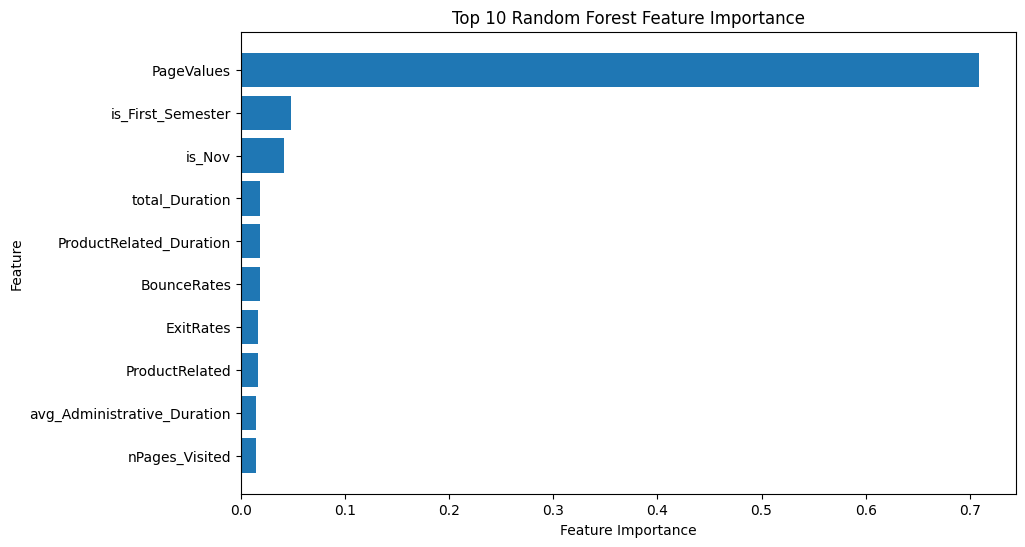

In [85]:
# Ambil feature importance
importance = rf_model.feature_importances_

# Nama fitur
feature_names = X_train.columns

# DataFrame importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Urutkan dari terbesar
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Ambil top 10
top10_features = importance_df.head(10)

print("\n")
print("="*60)
print("TOP 10 FEATURE IMPORTANCE - RANDOM FOREST")
print("="*60)

print(top10_features)

plt.figure(figsize=(10,6))

plt.barh(
    top10_features['Feature'][::-1],
    top10_features['Importance'][::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Random Forest Feature Importance')

plt.show()

# **XGBoost**

## **Library**

In [86]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import optuna

## **Scale Pos Weight**

In [87]:
negative_class = (y_train == 0).sum()
positive_class = (y_train == 1).sum()

scale_pos_weight_value = negative_class / positive_class

print("scale_pos_weight:", scale_pos_weight_value)

scale_pos_weight: 5.463958060288335


## **Def Hyperparameter Tuning**

In [ ]:
# def objective_xgb(trial):

#     params = {
#         'n_estimators': trial.suggest_int(
#             'n_estimators',
#             200,
#             3000
#         ),

#         'max_depth': trial.suggest_int(
#             'max_depth',
#             3,
#             12
#         ),

#         'learning_rate': trial.suggest_float(
#             'learning_rate',
#             0.005,
#             0.3,
#             log=True
#         ),

#         'min_child_weight': trial.suggest_int(
#             'min_child_weight',
#             1,
#             15
#         ),

#         'gamma': trial.suggest_float(
#             'gamma',
#             0,
#             10
#         ),

#         'subsample': trial.suggest_float(
#             'subsample',
#             0.5,
#             1.0
#         ),

#         'colsample_bytree': trial.suggest_float(
#             'colsample_bytree',
#             0.5,
#             1.0
#         ),

#         'reg_alpha': trial.suggest_float(
#             'reg_alpha',
#             1e-5,
#             10,
#             log=True
#         ),

#         'reg_lambda': trial.suggest_float(
#             'reg_lambda',
#             1e-5,
#             10,
#             log=True
#         ),


#         'scale_pos_weight': trial.suggest_float(
#             'scale_pos_weight',
#             scale_pos_weight_value * 0.5,
#             scale_pos_weight_value * 2
#         ),


#         'objective': 'binary:logistic',
#         'eval_metric': 'logloss',
#         'random_state': 42,
#         'tree_method': 'hist',
#         'n_jobs': -1
#     }

#     model = XGBClassifier(**params)

#     cv = StratifiedKFold(
#         n_splits=5,
#         shuffle=True,
#         random_state=42
#     )

#     score = cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=cv,
#         scoring='average_precision',
#         n_jobs=-1
#     ).mean()

#     return score

## **Hyperparameter Tuning**

In [ ]:
# study_xgb = optuna.create_study(
#     direction='maximize',
#     study_name='xgboost_optimization'
# )

# study_xgb.optimize(
#     objective_xgb,
#     n_trials=100,
#     show_progress_bar=True
# )

In [ ]:
# print("Best PR-AUC:", study_xgb.best_value)

# print("\nBest Parameters:")
# print(study_xgb.best_params)

## **Build Model Terbaik**

In [89]:
xgb_model = XGBClassifier(
    n_estimators=2551,
    max_depth=5,
    learning_rate=0.007194492645073406,
    min_child_weight=6,
    gamma=7.006379095968391,
    subsample=0.904236035337041,
    colsample_bytree=0.8179382104440102,
    reg_alpha=0.001610166107181125,
    reg_lambda=2.1812853930789304e-05,
    scale_pos_weight=3.445233420630672,
    use_label_encoder=False,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:51:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8179382104440102, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=7.006379095968391, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.007194492645073406,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=6, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2551, n_jobs=-1,
              num_parallel_tree=None, ...)

In [90]:
train_proba = xgb_model.predict_proba(X_train)[:,1]
test_proba  = xgb_model.predict_proba(X_test)[:,1]

## **Threshold Tuning**

In [91]:
thresholds = np.arange(0.05, 0.95, 0.01)

best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:

    preds = (train_proba >= threshold).astype(int)

    score = f1_score(y_train, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best Threshold :", best_threshold)
print("Best Train F1  :", best_f1)

Best Threshold : 0.6500000000000001
Best Train F1  : 0.7536694320357371


In [92]:
train_pred = (train_proba >= best_threshold).astype(int)
test_pred  = (test_proba >= best_threshold).astype(int)

## **Evaluasi**

In [93]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(y_true, y_pred, y_prob, dataset_name):

    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    prec = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    # LEBIH PENTING UNTUK IMBALANCE
    pr_auc = average_precision_score(
        y_true,
        y_prob
    )


    print(f"\n{'='*60}")
    print(f"{dataset_name} PERFORMANCE")
    print(f"{'='*60}")

    print(f"Accuracy           : {acc:.4f}")
    print(f"Balanced Accuracy  : {bal_acc:.4f}")
    print(f"Precision          : {prec:.4f}")
    print(f"Recall             : {rec:.4f}")
    print(f"F1-Score           : {f1:.4f}")
    print(f"ROC-AUC            : {roc_auc:.4f}")
    print(f"PR-AUC             : {pr_auc:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(
        y_true,
        y_pred,
        zero_division=0
    ))

In [94]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import ConfusionMatrixDisplay

evaluate_model(
    y_train,
    train_pred,
    train_proba,
    "TRAIN"
)

evaluate_model(
    y_test,
    test_pred,
    test_proba,
    "TEST"
)


TRAIN PERFORMANCE
Accuracy           : 0.9217
Balanced Accuracy  : 0.8614
Precision          : 0.7345
Recall             : 0.7739
F1-Score           : 0.7537
ROC-AUC            : 0.9611
PR-AUC             : 0.8390

Confusion Matrix
[[7911  427]
 [ 345 1181]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      8338
           1       0.73      0.77      0.75      1526

    accuracy                           0.92      9864
   macro avg       0.85      0.86      0.85      9864
weighted avg       0.92      0.92      0.92      9864


TEST PERFORMANCE
Accuracy           : 0.9019
Balanced Accuracy  : 0.8286
Precision          : 0.6699
Recall             : 0.7225
F1-Score           : 0.6952
ROC-AUC            : 0.9393
PR-AUC             : 0.7442

Confusion Matrix
[[1948  136]
 [ 106  276]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2084

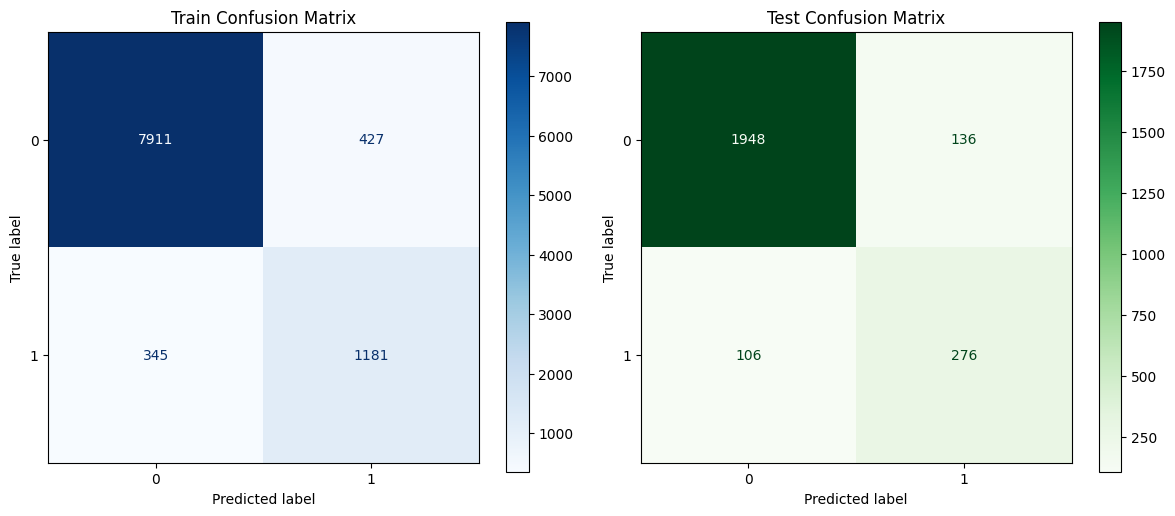

In [95]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# TRAIN
ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_pred,
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title('Train Confusion Matrix')

# TEST
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title('Test Confusion Matrix')

plt.tight_layout()
plt.show()

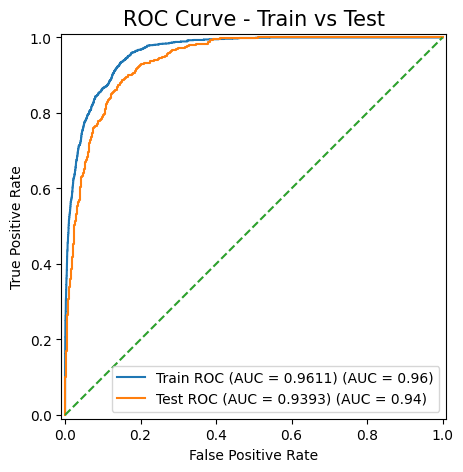

In [96]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    RocCurveDisplay,
    roc_auc_score
)

fig, ax = plt.subplots(figsize=(12,5))

RocCurveDisplay.from_predictions(
    y_train,
    train_proba,
    ax=ax,
    name=f'Train ROC (AUC = {roc_auc_score(y_train, train_proba):.4f})'
)

RocCurveDisplay.from_predictions(
    y_test,
    test_proba,
    ax=ax,
    name=f'Test ROC (AUC = {roc_auc_score(y_test, test_proba):.4f})'
)

ax.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

ax.set_title(
    'ROC Curve - Train vs Test',
    fontsize=15
)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

ax.legend(loc='lower right')

plt.show()

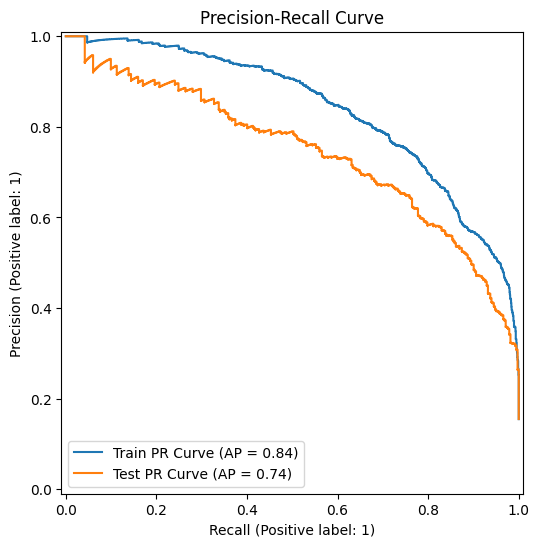

In [97]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(10,6))

# TRAIN
PrecisionRecallDisplay.from_predictions(
    y_train,
    train_proba,
    ax=ax,
    name='Train PR Curve'
)

# TEST
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_proba,
    ax=ax,
    name='Test PR Curve'
)

ax.set_title('Precision-Recall Curve')

plt.show()

## **Feature Importance**

In [98]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

In [99]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [100]:
top10_importance = importance_df.head(10)

print(top10_importance)

                    Feature  Importance
8                PageValues    0.272525
17        is_First_Semester    0.077559
28                   is_Nov    0.030476
7                 ExitRates    0.024865
22                   is_May    0.021631
6               BounceRates    0.018841
5   ProductRelated_Duration    0.018303
11           nPages_Visited    0.017493
4            ProductRelated    0.017290
20                   is_Mar    0.016529


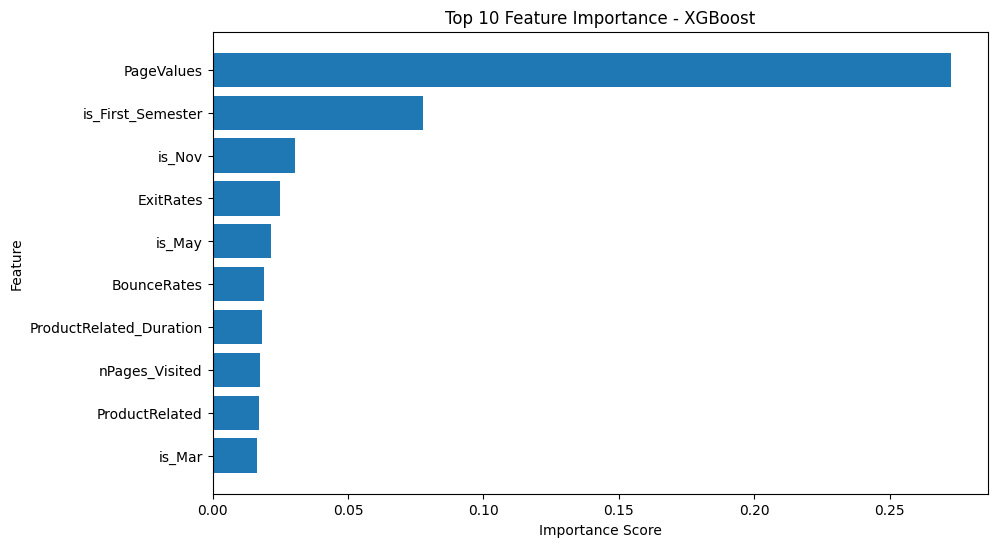

In [101]:
import matplotlib.pyplot as plt

top10_importance = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10_importance['Feature'],
    top10_importance['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - XGBoost")

plt.show()

# **LIGHTGBM**

## **Library**

In [102]:
import numpy as np
import pandas as pd

import lightgbm as lgb

from lightgbm import LGBMClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import matplotlib.pyplot as plt

import optuna

In [103]:
negative_class = (y_train == 0).sum()
positive_class = (y_train == 1).sum()

scale_pos_weight_value = negative_class / positive_class

print("scale_pos_weight:", scale_pos_weight_value)

scale_pos_weight: 5.463958060288335


## **Def Hyperparameter Tuning**

In [ ]:
# from lightgbm import LGBMClassifier, early_stopping
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# import optuna

# def objective_lgbm(trial):

#     params = {

#         # ======================
#         # BOOSTING PARAMETERS
#         # ======================

#         'n_estimators': trial.suggest_int(
#             'n_estimators',
#             100,
#             700
#         ),

#         'learning_rate': trial.suggest_float(
#             'learning_rate',
#             0.005,
#             0.2,
#             log=True
#         ),

#         'max_depth': trial.suggest_int(
#             'max_depth',
#             3,
#             12
#         ),

#         'num_leaves': trial.suggest_int(
#             'num_leaves',
#             15,
#             150
#         ),

#         'min_child_samples': trial.suggest_int(
#             'min_child_samples',
#             5,
#             100
#         ),

#         # ======================
#         # SAMPLING
#         # ======================

#         'feature_fraction': trial.suggest_float(
#             'feature_fraction',
#             0.6,
#             1.0
#         ),

#         'bagging_fraction': trial.suggest_float(
#             'bagging_fraction',
#             0.6,
#             1.0
#         ),

#         'bagging_freq': trial.suggest_int(
#             'bagging_freq',
#             1,
#             7
#         ),

#         # ======================
#         # REGULARIZATION
#         # ======================

#         'min_gain_to_split': trial.suggest_float(
#             'min_gain_to_split',
#             0,
#             5
#         ),

#         'lambda_l1': trial.suggest_float(
#             'lambda_l1',
#             1e-5,
#             10,
#             log=True
#         ),

#         'lambda_l2': trial.suggest_float(
#             'lambda_l2',
#             1e-5,
#             10,
#             log=True
#         ),

#         # ======================
#         # IMBALANCED DATA
#         # ======================

#         'scale_pos_weight': trial.suggest_float(
#             'scale_pos_weight',
#             scale_pos_weight_value * 0.8,
#             scale_pos_weight_value * 1.2
#         ),

#         # ======================
#         # FIXED PARAMETERS
#         # ======================

#         'objective': 'binary',
#         'metric': 'average_precision',

#         'device': 'gpu',
#         'gpu_platform_id': 0,
#         'gpu_device_id': 0,

#         'verbosity': -1,
#         'random_state': 42,

#         # PENTING:
#         # jangan -1 di sini
#         'n_jobs': 1,

#         # biasanya lebih cepat di kaggle
#         'force_col_wise': True
#     }

#     model = LGBMClassifier(**params)

#     cv = StratifiedKFold(
#         n_splits=3,
#         shuffle=True,
#         random_state=42
#     )

#     score = cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=cv,
#         scoring='average_precision',

#         # parallel CV
#         n_jobs=-1
#     ).mean()

#     return score


# # ======================
# # OPTUNA STUDY
# # ======================

# study_lgbm = optuna.create_study(
#     direction='maximize',
#     study_name='lightgbm_optimization'
# )

# study_lgbm.optimize(
#     objective_lgbm,
#     n_trials=50,
#     show_progress_bar=True
# )


# # ======================
# # HASIL TERBAIK
# # ======================

# print("Best Score:")
# print(study_lgbm.best_value)

# print("\nBest Params:")
# print(study_lgbm.best_params)

[I 2026-05-11 13:59:06,302] A new study created in memory with name: lightgbm_optimization


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-11 13:59:13,267] Trial 0 finished with value: 0.7360186543730077 and parameters: {'n_estimators': 160, 'learning_rate': 0.014804790322563346, 'max_depth': 12, 'num_leaves': 63, 'min_child_samples': 47, 'feature_fraction': 0.6708684896625227, 'bagging_fraction': 0.9219147728389867, 'bagging_freq': 1, 'min_gain_to_split': 3.776689750167852, 'lambda_l1': 0.07754059070937051, 'lambda_l2': 7.599712945130466, 'scale_pos_weight': 5.91860233130185}. Best is trial 0 with value: 0.7360186543730077.
[I 2026-05-11 13:59:17,494] Trial 1 finished with value: 0.7417830006285923 and parameters: {'n_estimators': 369, 'learning_rate': 0.006940723724420344, 'max_depth': 3, 'num_leaves': 79, 'min_child_samples': 86, 'feature_fraction': 0.6951997368672569, 'bagging_fraction': 0.9463964895887437, 'bagging_freq': 3, 'min_gain_to_split': 2.0713339484715307, 'lambda_l1': 1.6349401784717258e-05, 'lambda_l2': 4.415957799006009, 'scale_pos_weight': 4.506042786717709}. Best is trial 1 with value: 0.7417

## **Build Model Terbaik**

In [105]:

from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=622,
    learning_rate=0.007886747691112401,
    max_depth=5,
    num_leaves=100,
    min_child_samples=41,
    feature_fraction=0.9794013809706857,
    bagging_fraction=0.9135292486015985,
    bagging_freq=7,
    min_gain_to_split=0.3288923912819831,
    lambda_l1=0.0181051523394834,
    lambda_l2=0.003394729469310363,
    scale_pos_weight=4.463680438742386,
    objective='binary',
    metric='average_precision',
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

LGBMClassifier(bagging_fraction=0.9135292486015985, bagging_freq=7,
               feature_fraction=0.9794013809706857,
               lambda_l1=0.0181051523394834, lambda_l2=0.003394729469310363,
               learning_rate=0.007886747691112401, max_depth=5,
               metric='average_precision', min_child_samples=41,
               min_gain_to_split=0.3288923912819831, n_estimators=622,
               n_jobs=-1, num_leaves=100, objective='binary', random_state=42,
               scale_pos_weight=4.463680438742386, verbosity=-1)

In [106]:
train_proba = lgbm_model.predict_proba(X_train)[:,1]
test_proba  = lgbm_model.predict_proba(X_test)[:,1]

## **Threshold Tuning**

In [107]:
thresholds = np.arange(0.05, 0.95, 0.01)

best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:

    preds = (train_proba >= threshold).astype(int)

    score = f1_score(y_train, preds)

    if score > best_f1:

        best_f1 = score
        best_threshold = threshold

print("Best Threshold :", best_threshold)
print("Best Train F1  :", best_f1)

Best Threshold : 0.6900000000000002
Best Train F1  : 0.7456445993031359


In [108]:
train_pred = (train_proba >= best_threshold).astype(int)
test_pred  = (test_proba >= best_threshold).astype(int)

## **Evaluasi**

In [109]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(y_true, y_pred, y_prob, dataset_name):

    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    prec = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    # LEBIH PENTING UNTUK IMBALANCE
    pr_auc = average_precision_score(
        y_true,
        y_prob
    )


    print(f"\n{'='*60}")
    print(f"{dataset_name} PERFORMANCE")
    print(f"{'='*60}")

    print(f"Accuracy           : {acc:.4f}")
    print(f"Balanced Accuracy  : {bal_acc:.4f}")
    print(f"Precision          : {prec:.4f}")
    print(f"Recall             : {rec:.4f}")
    print(f"F1-Score           : {f1:.4f}")
    print(f"ROC-AUC            : {roc_auc:.4f}")
    print(f"PR-AUC             : {pr_auc:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(
        y_true,
        y_pred,
        zero_division=0
    ))

In [110]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import ConfusionMatrixDisplay

evaluate_model(
    y_train,
    train_pred,
    train_proba,
    "TRAIN"
)

evaluate_model(
    y_test,
    test_pred,
    test_proba,
    "TEST"
)


TRAIN PERFORMANCE
Accuracy           : 0.9186
Balanced Accuracy  : 0.8584
Precision          : 0.7216
Recall             : 0.7713
F1-Score           : 0.7456
ROC-AUC            : 0.9590
PR-AUC             : 0.8347

Confusion Matrix
[[7884  454]
 [ 349 1177]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      8338
           1       0.72      0.77      0.75      1526

    accuracy                           0.92      9864
   macro avg       0.84      0.86      0.85      9864
weighted avg       0.92      0.92      0.92      9864


TEST PERFORMANCE
Accuracy           : 0.9006
Balanced Accuracy  : 0.8279
Precision          : 0.6651
Recall             : 0.7225
F1-Score           : 0.6926
ROC-AUC            : 0.9390
PR-AUC             : 0.7462

Confusion Matrix
[[1945  139]
 [ 106  276]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2084

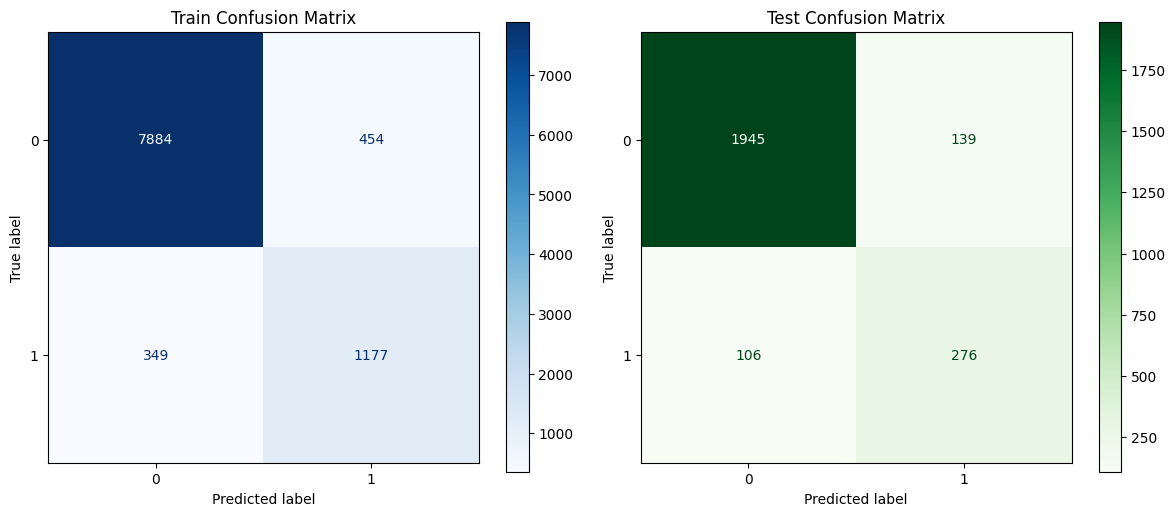

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# TRAIN
ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_pred,
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title('Train Confusion Matrix')

# TEST
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title('Test Confusion Matrix')

plt.tight_layout()
plt.show()

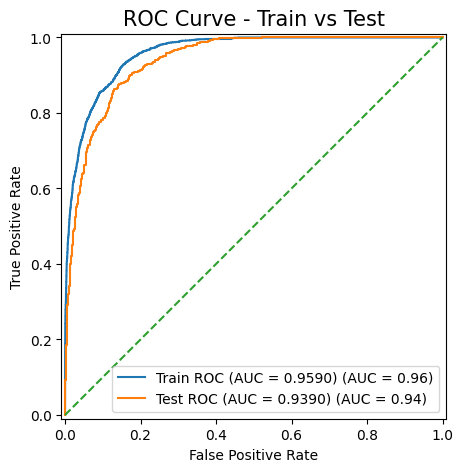

In [112]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    RocCurveDisplay,
    roc_auc_score
)

fig, ax = plt.subplots(figsize=(12,5))

RocCurveDisplay.from_predictions(
    y_train,
    train_proba,
    ax=ax,
    name=f'Train ROC (AUC = {roc_auc_score(y_train, train_proba):.4f})'
)

RocCurveDisplay.from_predictions(
    y_test,
    test_proba,
    ax=ax,
    name=f'Test ROC (AUC = {roc_auc_score(y_test, test_proba):.4f})'
)

ax.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

ax.set_title(
    'ROC Curve - Train vs Test',
    fontsize=15
)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

ax.legend(loc='lower right')

plt.show()

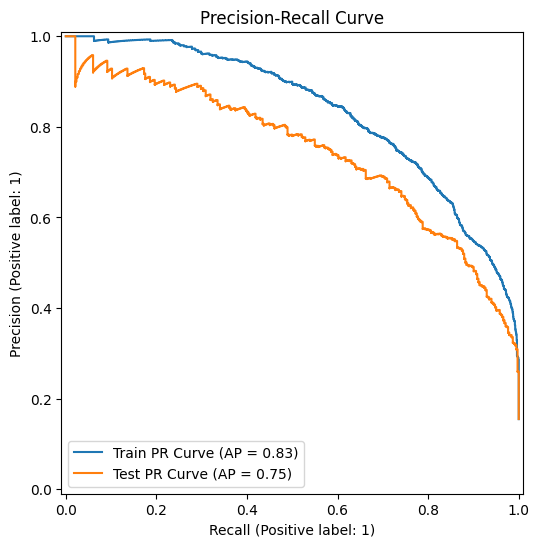

In [113]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(10,6))

# TRAIN
PrecisionRecallDisplay.from_predictions(
    y_train,
    train_proba,
    ax=ax,
    name='Train PR Curve'
)

# TEST
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_proba,
    ax=ax,
    name='Test PR Curve'
)

ax.set_title('Precision-Recall Curve')

plt.show()

## **Feature Importance**

In [114]:
importance_df = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': lgbm_model.feature_importances_
})

In [115]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [116]:
top10_importance = importance_df.head(10)

print(top10_importance)

                        Feature  Importance
8                    PageValues        1458
7                     ExitRates        1356
0                Administrative         857
1       Administrative_Duration         845
13  avg_Administrative_Duration         771
6                   BounceRates         731
5       ProductRelated_Duration         663
12               total_Duration         615
11               nPages_Visited         596
16        avg_Duration_Per_Page         571


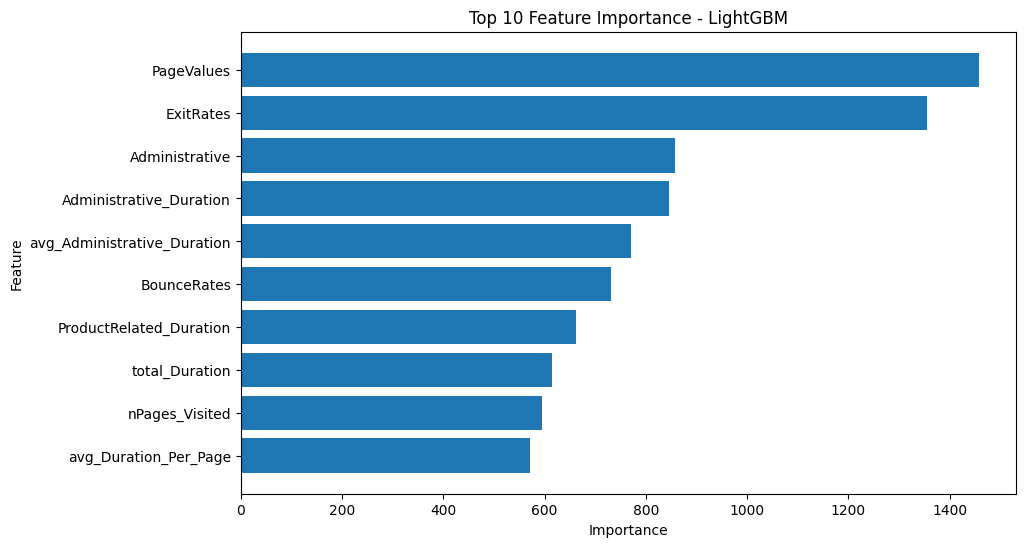

In [117]:
plt.figure(figsize=(10,6))

plt.barh(
    top10_importance['Feature'],
    top10_importance['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 10 Feature Importance - LightGBM")

plt.show()

# **STACKING ENSEMBLE XGBOOST CLASSIFIER**

## **Library**

In [118]:
import numpy as np
import pandas as pd

from sklearn.ensemble import StackingClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import optuna

## **Base Model**

In [119]:
logreg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        solver='liblinear',
        penalty='l1',
        C=0.0015869990932290139,
        max_iter=2855,
        class_weight='balanced',
        random_state=42
    ))
])

rf_model = RandomForestClassifier(
    n_estimators=1311,
    max_depth=9,
    min_samples_split=20,
    min_samples_leaf=19,
    max_features=None,
    bootstrap=True,
    class_weight='balanced_subsample',
    ccp_alpha=2.2179315968457164e-05,
    random_state=42,
    n_jobs=-1
)

lgbm_model = LGBMClassifier(
    n_estimators=622,
    learning_rate=0.007886747691112401,
    max_depth=5,
    num_leaves=100,
    min_child_samples=41,
    feature_fraction=0.9794013809706857,
    bagging_fraction=0.9135292486015985,
    bagging_freq=7,
    min_gain_to_split=0.3288923912819831,
    lambda_l1=0.0181051523394834,
    lambda_l2=0.003394729469310363,
    scale_pos_weight=4.463680438742386,
    objective='binary',
    metric='average_precision',
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
    force_col_wise=True
)

lgbm_model.fit(X_train, y_train)

LGBMClassifier(bagging_fraction=0.9135292486015985, bagging_freq=7,
               feature_fraction=0.9794013809706857, force_col_wise=True,
               lambda_l1=0.0181051523394834, lambda_l2=0.003394729469310363,
               learning_rate=0.007886747691112401, max_depth=5,
               metric='average_precision', min_child_samples=41,
               min_gain_to_split=0.3288923912819831, n_estimators=622,
               n_jobs=-1, num_leaves=100, objective='binary', random_state=42,
               scale_pos_weight=4.463680438742386, verbosity=-1)

## **Def Hyperparameter Tuning**

In [37]:
# from sklearn.ensemble import StackingClassifier
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from xgboost import XGBClassifier
# import optuna

# def objective_stacking(trial):
#     meta_model = XGBClassifier(
#         n_estimators=trial.suggest_int(
#             'n_estimators',
#             50,
#             200
#         ),

#         max_depth=trial.suggest_int(
#             'max_depth',
#             2,
#             5
#         ),

#         learning_rate=trial.suggest_float(
#             'learning_rate',
#             0.03,
#             0.2,
#             log=True
#         ),

#         subsample=trial.suggest_float(
#             'subsample',
#             0.7,
#             1.0
#         ),

#         colsample_bytree=trial.suggest_float(
#             'colsample_bytree',
#             0.7,
#             1.0
#         ),

#         gamma=trial.suggest_float(
#             'gamma',
#             0,
#             3
#         ),

#         min_child_weight=trial.suggest_int(
#             'min_child_weight',
#             1,
#             6
#         ),

#         reg_alpha=trial.suggest_float(
#             'reg_alpha',
#             1e-4,
#             1,
#             log=True
#         ),

#         reg_lambda=trial.suggest_float(
#             'reg_lambda',
#             1e-4,
#             1,
#             log=True
#         ),

#         scale_pos_weight=trial.suggest_float(
#             'scale_pos_weight',
#             scale_pos_weight_value * 0.9,
#             scale_pos_weight_value * 1.1
#         ),

#         objective='binary:logistic',

#         eval_metric='logloss',
#         tree_method='hist',

#         device='cpu',

#         random_state=42,

#         n_jobs=1
#     )

#     stack_model = StackingClassifier(

#         estimators=[

#             ('logreg', logreg_model),

#             ('rf', rf_model),

#             ('lgbm', lgbm_model)

#         ],

#         final_estimator=meta_model,

#         stack_method='predict_proba',

#         passthrough=trial.suggest_categorical(
#             'passthrough',
#             [True, False]
#         ),

#         cv=2,

#         n_jobs=1
#     )


#     cv_outer = StratifiedKFold(

#         n_splits=2,

#         shuffle=True,

#         random_state=42
#     )

#     score = cross_val_score(

#         stack_model,

#         X_train,

#         y_train,

#         cv=cv_outer,

#         scoring='average_precision',

#         # parallel hanya di sini
#         n_jobs=-1

#     ).mean()

#     return score

# study_stack = optuna.create_study(

#     direction='maximize',

#     study_name='stacking_optimization',

#     sampler=optuna.samplers.TPESampler(
#         seed=42
#     )
# )

# study_stack.optimize(

#     objective_stacking,

#     # awalnya jangan terlalu besar
#     n_trials=20,

#     show_progress_bar=True
# )

# print("=" * 50)

# print("Best Score:")
# print(study_stack.best_value)

# print("\nBest Parameters:")
# print(study_stack.best_params)

# print("=" * 50)

[I 2026-05-12 00:27:58,484] A new study created in memory with name: stacking_optimization


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-12 00:31:16,108] Trial 0 finished with value: 0.7214168308411526 and parameters: {'n_estimators': 106, 'max_depth': 5, 'learning_rate': 0.12028665880905137, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'gamma': 0.46798356100860794, 'min_child_weight': 1, 'reg_alpha': 0.29154431891537513, 'reg_lambda': 0.02537815508265665, 'scale_pos_weight': 5.69133802800307, 'passthrough': False}. Best is trial 0 with value: 0.7214168308411526.
[I 2026-05-12 00:34:28,346] Trial 1 finished with value: 0.7480350346683096 and parameters: {'n_estimators': 175, 'max_depth': 2, 'learning_rate': 0.04235731615410186, 'subsample': 0.7550213529560301, 'colsample_bytree': 0.7912726728878613, 'gamma': 1.5742692948967134, 'min_child_weight': 3, 'reg_alpha': 0.0014618962793704966, 'reg_lambda': 0.0280163515871626, 'scale_pos_weight': 5.0699999751135945, 'passthrough': False}. Best is trial 1 with value: 0.7480350346683096.
[I 2026-05-12 00:37:38,387] Trial 2 finished with valu

## **Meta Model**

In [120]:
meta_model_final = XGBClassifier(
    n_estimators=167,
    max_depth=4,
    learning_rate=0.03853929900373742,
    subsample=0.7712021241893436,
    colsample_bytree=0.945701392009707,
    reg_alpha=0.00444336066405073,
    reg_lambda=0.08164522092122309,
    gamma=0.7749402048510978,
    min_child_weight=6,
    scale_pos_weight=5.027792313787965,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    device='cuda',
    random_state=42,
    n_jobs=-1
)

## **Stacking Final**

In [135]:
stack_model = StackingClassifier(

    estimators=[

        ('logreg', logreg_model),

        ('rf', rf_model),

        ('lgbm', lgbm_model)
    ],

    final_estimator=meta_model_final,

    stack_method='predict_proba',

    passthrough=False,

    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),

    n_jobs=-1
)

In [136]:
stack_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:09:28] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:09:28] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('logreg',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('model',
                                                 LogisticRegression(C=0.0015869990932290139,
                                                                    class_weight='balanced',
                                                                    max_iter=2855,
                                                                    penalty='l1',
                                                                    random_state=42,
                                                                    solver='liblinear'))])),
                               ('rf',
                                RandomForestClassifier(ccp_alpha=2.2179315968457164e-05,...
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.03853929900373742,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=4, max_leaves=None,
                                                 min_child_weight=6,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=167, n_jobs=-1,
                                                 num_parallel_tree=None, ...),
                   n_jobs=-1, stack_method='predict_proba')

In [137]:
train_proba = stack_model.predict_proba(X_train)[:,1]
test_proba  = stack_model.predict_proba(X_test)[:,1]

## **Threshold Tuning**

In [138]:
thresholds = np.arange(0.05, 0.95, 0.01)

best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:

    preds = (train_proba >= threshold).astype(int)

    score = f1_score(y_train, preds)

    if score > best_f1:

        best_f1 = score
        best_threshold = threshold

print("Best Threshold :", best_threshold)
print("Best Train F1  :", best_f1)

Best Threshold : 0.7000000000000002
Best Train F1  : 0.7464998510574918


In [139]:
train_pred = (train_proba >= best_threshold).astype(int)
test_pred  = (test_proba >= best_threshold).astype(int)

## **Evaluasi**

In [140]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
)

from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_model(y_true, y_pred, y_prob, dataset_name):

    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    prec = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    # LEBIH PENTING UNTUK IMBALANCE
    pr_auc = average_precision_score(
        y_true,
        y_prob
    )


    print(f"\n{'='*60}")
    print(f"{dataset_name} PERFORMANCE")
    print(f"{'='*60}")

    print(f"Accuracy           : {acc:.4f}")
    print(f"Balanced Accuracy  : {bal_acc:.4f}")
    print(f"Precision          : {prec:.4f}")
    print(f"Recall             : {rec:.4f}")
    print(f"F1-Score           : {f1:.4f}")
    print(f"ROC-AUC            : {roc_auc:.4f}")
    print(f"PR-AUC             : {pr_auc:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(
        y_true,
        y_pred,
        zero_division=0
    ))

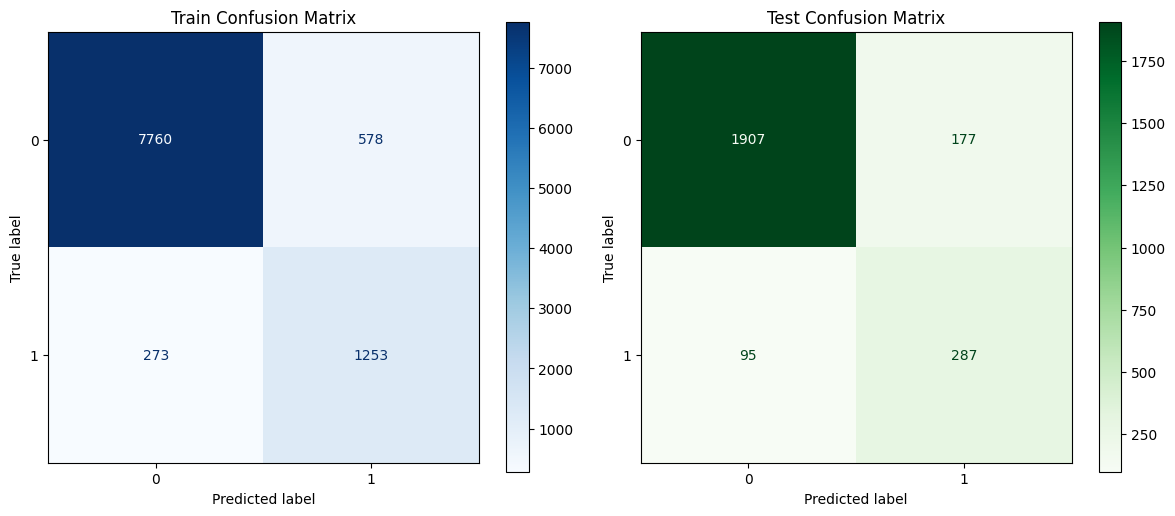

In [141]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# TRAIN
ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_pred,
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title('Train Confusion Matrix')

# TEST
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title('Test Confusion Matrix')

plt.tight_layout()
plt.show()

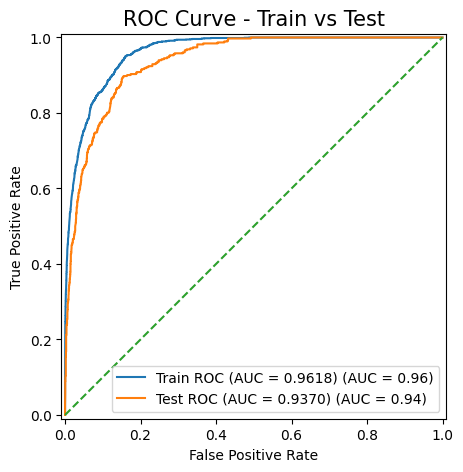

In [142]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    RocCurveDisplay,
    roc_auc_score
)

fig, ax = plt.subplots(figsize=(12,5))

RocCurveDisplay.from_predictions(
    y_train,
    train_proba,
    ax=ax,
    name=f'Train ROC (AUC = {roc_auc_score(y_train, train_proba):.4f})'
)

RocCurveDisplay.from_predictions(
    y_test,
    test_proba,
    ax=ax,
    name=f'Test ROC (AUC = {roc_auc_score(y_test, test_proba):.4f})'
)

ax.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

ax.set_title(
    'ROC Curve - Train vs Test',
    fontsize=15
)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

ax.legend(loc='lower right')

plt.show()

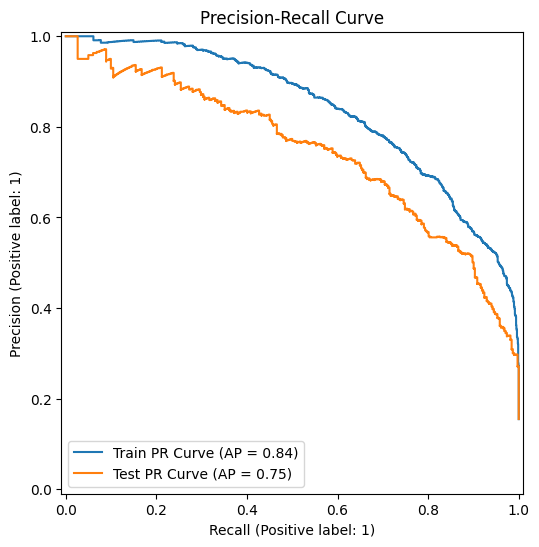

In [143]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(10,6))

# TRAIN
PrecisionRecallDisplay.from_predictions(
    y_train,
    train_proba,
    ax=ax,
    name='Train PR Curve'
)

# TEST
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_proba,
    ax=ax,
    name='Test PR Curve'
)

ax.set_title('Precision-Recall Curve')

plt.show()

# **Feature Importance**

In [144]:
meta_model = stack_model.final_estimator_

In [145]:
meta_features = [

    'LogReg_Prob',

    'RF_Prob',

    'LGBM_Prob'
]

In [146]:
importance_df = pd.DataFrame({

    'Feature': meta_features,

    'Importance': meta_model.feature_importances_
})

In [147]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)
print(importance_df)

       Feature  Importance
2    LGBM_Prob    0.538030
1      RF_Prob    0.417939
0  LogReg_Prob    0.044031


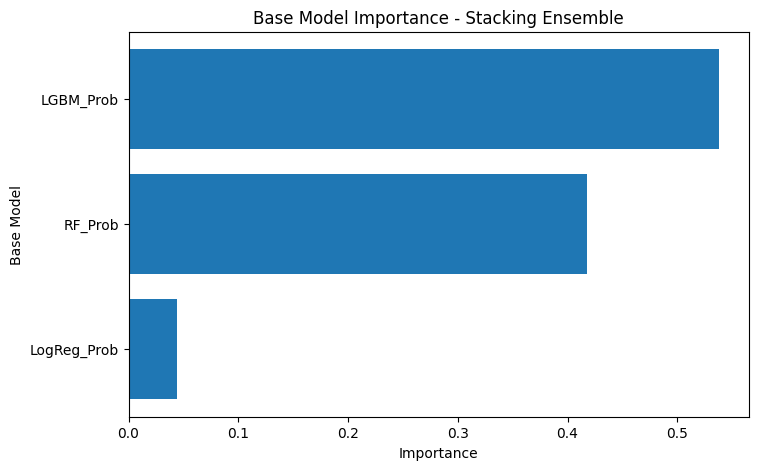

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Base Model")

plt.title("Base Model Importance - Stacking Ensemble")

plt.show()